In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

In [22]:
df = pd.read_csv('processed_data.csv')

X = df.drop(columns=['Stars Count'])
y = df['Stars Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (2049, 101)
Test shape: (513, 101)


In [23]:
forest_model = RandomForestRegressor(
    random_state=18,
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    max_features='sqrt'
)
forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

baseline_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2_log': r2_score(y_test, y_pred),
    'OOB_R2_log': forest_model.oob_score_,
    'MAE': mean_absolute_error(y_test_original, y_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
}

pd.DataFrame([baseline_metrics], index=['Random Forest baseline'])

,MAE_log,RMSE_log,R2_log,OOB_R2_log,MAE,RMSE
Random Forest baseline,0.368331,0.487141,0.869591,0.862983,6337.443813,14681.691077


In [25]:
param_grid = [{
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 50, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
    'oob_score' : [True, False]
},
{ 
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 50, 100, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [False],
    'oob_score' : [False]
}]

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV score:', -grid_search.best_score_)

Best params: {'bootstrap': False, 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'oob_score': False}
Best CV score: 0.49936513241254643


In [ ]:
best_forest = grid_search.best_estimator_
y_pred_best = best_forest.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_best_original = np.expm1(y_pred_best)

tuned_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred_best),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred_best)),
    'R2_log': r2_score(y_test, y_pred_best),
    'MAE': mean_absolute_error(y_test_original, y_pred_best_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_best_original)),
}

pd.DataFrame([
    baseline_metrics,
    tuned_metrics
], index=['Random Forest baseline', 'Random Forest tuned'])

,MAE_log,RMSE_log,R2_log,OOB_R2_log,MAE,RMSE
Random Forest baseline,0.368331,0.487141,0.869591,0.862983,6337.443813,14681.691077
Random Forest tuned,0.364541,0.483560,0.871501,NaN,6375.323268,15105.332300


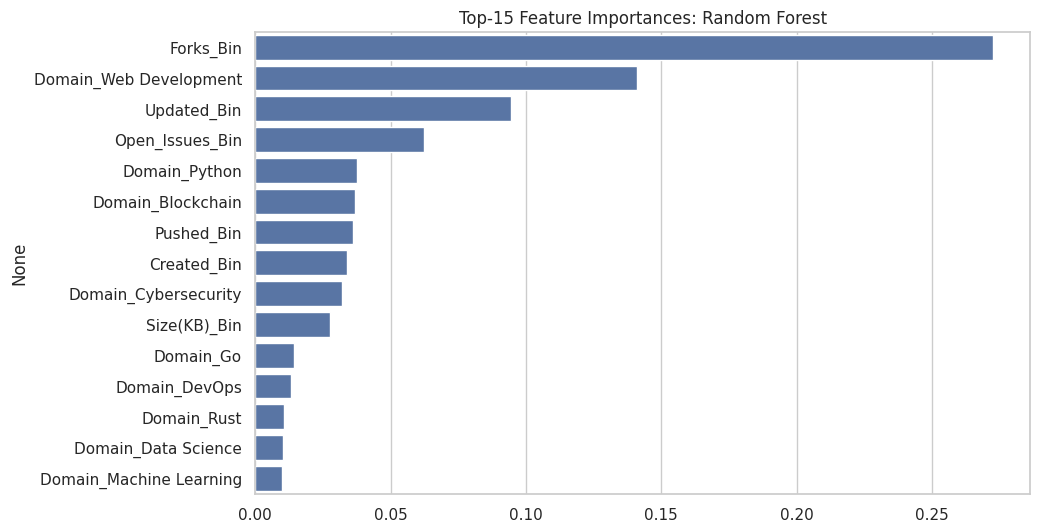

In [ ]:
#Base лес показал результаты лучше - берем его
feature_importance = pd.Series(forest_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('Top-15 Feature Importances: Random Forest')
plt.show()